# Dataset Loading, Preprocessing and Train-Test Split

## Objective
To load the Wisconsin Diagnostic Breast Cancer dataset, preprocess the data, encode the target variable, and split the dataset into training and testing sets using an 80:20 ratio.

## 1. Load the Dataset

The Wisconsin Diagnostic Breast Cancer dataset contains 569 samples,
30 numerical features, and a target variable representing Malignant (M)
and Benign (B) classes.

In [13]:
import pandas as pd
import numpy as np

df=pd.read_csv("wdbc.data",header=None)
print(df)
print("Dataset Loaded successfully")

           0  1      2      3       4       5        6        7        8   \
0      842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.30010   
1      842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.08690   
2    84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.19740   
3    84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.24140   
4    84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.19800   
..        ... ..    ...    ...     ...     ...      ...      ...      ...   
564    926424  M  21.56  22.39  142.00  1479.0  0.11100  0.11590  0.24390   
565    926682  M  20.13  28.25  131.20  1261.0  0.09780  0.10340  0.14400   
566    926954  M  16.60  28.08  108.30   858.1  0.08455  0.10230  0.09251   
567    927241  M  20.60  29.33  140.10  1265.0  0.11780  0.27700  0.35140   
568     92751  B   7.76  24.54   47.92   181.0  0.05263  0.04362  0.00000   

          9   ...      22     23      24      25       26       27      28 

## 2. Assign Column Names

The first column represents the ID, the second column represents the
diagnosis, and the remaining 30 columns represent the numerical features.

In [14]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se",
    "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = columns
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Basic Dataset Inspection

Check the dataset shape, data types, missing values, and statistical summary.

In [15]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

(569, 32)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             56

## 4. Separate Features and Target

The `diagnosis` column is the target variable, while the remaining
numerical attributes are used as input features.

In [16]:
X=df.drop(columns=["id","diagnosis"])
Y=df["diagnosis"]

print(X.shape)
print(Y.shape)

(569, 30)
(569,)


## 5. Encode the Target Variable

The diagnosis contains two categorical classes:
- B – Benign
- M – Malignant

Label Encoding is used to convert these classes into numerical values.

In [17]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split

encoder=LabelEncoder()
y=encoder.fit_transform(Y)
print("Encoded classes :",encoder.classes_)


Encoded classes : ['B' 'M']


## 6. Feature Scaling

StandardScaler is used to standardize the numerical features so that
the features have a comparable scale.

In [18]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled.shape)

(569, 30)


## 7. Train-Test Split

The dataset is divided into 80% training data and 20% testing data.
The training data is used to build the ensemble models, while the testing
data is used for final performance evaluation.

In [19]:
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", Y_train.shape)
print("Testing Target:", Y_test.shape)

Training Features: (455, 30)
Testing Features: (114, 30)
Training Target: (455,)
Testing Target: (114,)


# Bagging

## Objective
To implement a Bagging classifier using Decision Trees as the base estimator
and select suitable hyperparameters using 5-fold cross-validation.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

base_model=DecisionTreeClassifier(random_state=42)
base_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 3. Create the Bagging Classifier

The Bagging classifier creates multiple Decision Tree models using
different bootstrap samples of the training data.

In [21]:
bagging_model=BaggingClassifier(estimator=base_model,random_state=42)
bagging_model

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


## 4. Train the Bagging Model

The Bagging classifier is trained using the training dataset obtained
from the 80:20 train-test split performed in Part 1.

In [22]:
bagging_model.fit(X_train,Y_train)

y_pred_bag=bagging_model.predict(X_test)
print(y_pred_bag[:10])

[0 1 1 0 0 1 1 1 1 0]


## 6. Define Hyperparameter Combinations

The Bagging classifier will be evaluated using different values of
n_estimators, max_samples, and max_features.

In [23]:
parameter_combinations = [
    {"n_estimators": 10, "max_samples": 0.8, "max_features": 1.0},
    {"n_estimators": 50, "max_samples": 0.8, "max_features": 1.0},
    {"n_estimators": 100, "max_samples": 0.8, "max_features": 1.0},
    {"n_estimators": 50, "max_samples": 0.7, "max_features": 0.8},
    {"n_estimators": 100, "max_samples": 0.7, "max_features": 0.8}
]

parameter_combinations

[{'n_estimators': 10, 'max_samples': 0.8, 'max_features': 1.0},
 {'n_estimators': 50, 'max_samples': 0.8, 'max_features': 1.0},
 {'n_estimators': 100, 'max_samples': 0.8, 'max_features': 1.0},
 {'n_estimators': 50, 'max_samples': 0.7, 'max_features': 0.8},
 {'n_estimators': 100, 'max_samples': 0.7, 'max_features': 0.8}]

## 7. Perform 5-Fold Cross-Validation

Each hyperparameter combination is evaluated using 5-fold cross-validation.
Accuracy and F1-score are used as evaluation metrics.

In [24]:
from sklearn.model_selection import cross_validate
results = []

for params in parameter_combinations:

    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=params["n_estimators"],
        max_samples=params["max_samples"],
        max_features=params["max_features"],
        random_state=42
    )

    scores = cross_validate(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring=["accuracy", "f1"]
    )

    results.append({
        "n_estimators": params["n_estimators"],
        "max_samples": params["max_samples"],
        "max_features": params["max_features"],
        "Avg CV Accuracy": scores["test_accuracy"].mean(),
        "Avg CV F1": scores["test_f1"].mean()
    })

## 8. Display Bagging Hyperparameter Evaluation Results

The cross-validation results for all tested hyperparameter combinations
are converted into a DataFrame for comparison.

In [25]:
results_df = pd.DataFrame(results)

results_df

,n_estimators,max_samples,max_features,Avg CV Accuracy,Avg CV F1
0,10,0.8,1.0,0.936264,0.912033
1,50,0.8,1.0,0.949451,0.930664
2,100,0.8,1.0,0.947253,0.927416
3,50,0.7,0.8,0.945055,0.924510
4,100,0.7,0.8,0.947253,0.927491


## 9. Select the Best Hyperparameter Combination

The hyperparameter combination with the highest average cross-validation
accuracy is selected as the best Bagging configuration.

In [26]:
best_result=results_df.loc[results_df["Avg CV Accuracy"].idxmax()]
print(best_result)

n_estimators       50.000000
max_samples         0.800000
max_features        1.000000
Avg CV Accuracy     0.949451
Avg CV F1           0.930664
Name: 1, dtype: float64


## 10. Train the Final Bagging Model

The best hyperparameter combination selected using 5-fold cross-validation
is used to train the final Bagging classifier on the complete training set.

In [27]:
best_bagging=BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=int(best_result["n_estimators"]),
    max_samples=best_result["max_samples"],
    max_features=best_result["max_features"],
    random_state=42
)
best_bagging.fit(X_train,Y_train)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",np.float64(0.8)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",np.float64(1.0)
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


#  Boosting

## Objective
To implement Boosting classifiers using AdaBoost and Gradient Boosting
and evaluate their hyperparameters using 5-fold cross-validation.

## 1. Import Required Libraries

AdaBoost and Gradient Boosting are used to build sequential ensemble models.
A Decision Tree is used as the base estimator for AdaBoost.

In [28]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier


## 2. Create the AdaBoost Model

AdaBoost trains weak learners sequentially, with each new learner focusing
more on the samples that were incorrectly classified by previous learners.

In [29]:
ada_model=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,random_state=42),
                             random_state=42)
ada_model

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


## 3. Define AdaBoost Hyperparameters

Different values of the number of estimators and learning rate will be
evaluated using 5-fold cross-validation.

In [30]:
ada_parameters = [
    {"n_estimators": 50, "learning_rate": 0.5},
    {"n_estimators": 50, "learning_rate": 1.0},
    {"n_estimators": 100, "learning_rate": 0.5},
    {"n_estimators": 100, "learning_rate": 1.0}
]

## 4. Perform 5-Fold Cross-Validation for AdaBoost

Each AdaBoost hyperparameter combination is evaluated using 5-fold
cross-validation with Accuracy and F1-score.

In [31]:
ada_results=[]

for params in ada_parameters:
    model=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1,random_state=42),
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        random_state=42
    )


    scores=cross_validate(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring=["accuracy","f1"]
    )

    ada_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "Avg CV Accuracy": scores["test_accuracy"].mean(),
        "Avg CV F1": scores["test_f1"].mean()
    })
    
    

## 5. Display AdaBoost Results

The average cross-validation Accuracy and F1-score for each AdaBoost
hyperparameter combination are displayed for comparison.

In [32]:
ada_results_df = pd.DataFrame(ada_results)

ada_results_df

,n_estimators,learning_rate,Avg CV Accuracy,Avg CV F1
0,50,0.5,0.967033,0.953854
1,50,1.0,0.980220,0.972766
2,100,0.5,0.971429,0.960156
3,100,1.0,0.975824,0.966598


## 6. Select the Best AdaBoost Configuration

The AdaBoost configuration with the highest average cross-validation
accuracy is selected.

In [33]:
best_ada_result = ada_results_df.loc[
    ada_results_df["Avg CV Accuracy"].idxmax()
]

best_ada_result

n_estimators       50.000000
learning_rate       1.000000
Avg CV Accuracy     0.980220
Avg CV F1           0.972766
Name: 1, dtype: float64

## 7. Train the Final AdaBoost Model

The best AdaBoost hyperparameters obtained from cross-validation are used
to train the final AdaBoost model on the complete training dataset.

In [34]:
best_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=int(best_ada_result["n_estimators"]),
    learning_rate=best_ada_result["learning_rate"],
    random_state=42
)

best_ada.fit(X_train, Y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",np.float64(1.0)
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.08,0.14,0.16,...,0.4 ,0.41,0.31]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[2.45,1.85,1.65,...,0.4 ,0.35,0.82]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](30,)","[0. ,0.07,0. ,...,0.07,0.08,0. ]"


## 8. Create the Gradient Boosting Model

Gradient Boosting builds models sequentially, with each new model
attempting to improve the errors made by the previous models.

In [35]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

## 9. Define Gradient Boosting Hyperparameters

The number of estimators, learning rate, and maximum depth are explored
for Gradient Boosting.

In [36]:
gb_parameters = [
    {"n_estimators": 50, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 50, "learning_rate": 0.1, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3}
]

## 10. Perform 5-Fold Cross-Validation for Gradient Boosting

Each Gradient Boosting hyperparameter combination is evaluated using
5-fold cross-validation with Accuracy and F1-score.

In [37]:
gb_results = []

for params in gb_parameters:

    model = GradientBoostingClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42
    )

    scores = cross_validate(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring=["accuracy", "f1"]
    )

    gb_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "Avg CV Accuracy": scores["test_accuracy"].mean(),
        "Avg CV F1": scores["test_f1"].mean()
    })

gb_results_df = pd.DataFrame(gb_results)

gb_results_df

,n_estimators,learning_rate,max_depth,Avg CV Accuracy,Avg CV F1
0,50,0.05,2,0.949451,0.930733
1,50,0.10,2,0.951648,0.933398
2,100,0.05,2,0.958242,0.942071
3,100,0.10,3,0.951648,0.933657


## 12. Select the Best Gradient Boosting Configuration

The Gradient Boosting configuration with the highest average
cross-validation accuracy is selected.

In [38]:
best_gb_result = gb_results_df.loc[
    gb_results_df["Avg CV Accuracy"].idxmax()
]

best_gb_result



n_estimators       100.000000
learning_rate        0.050000
max_depth            2.000000
Avg CV Accuracy      0.958242
Avg CV F1            0.942071
Name: 2, dtype: float64

In [39]:
best_gb = GradientBoostingClassifier(
    n_estimators=int(best_gb_result["n_estimators"]),
    learning_rate=best_gb_result["learning_rate"],
    max_depth=int(best_gb_result["max_depth"]),
    random_state=42
)

best_gb.fit(X_train, Y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",np.float64(0.05)
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: 

#  Stacked Ensemble

## Objective
To implement a Stacked Ensemble using SVM, Naïve Bayes, and Decision Tree
as base models and Logistic Regression as the meta-learner.

## 1. Import Required Libraries

SVM, Naïve Bayes, and Decision Tree are used as the base models.
Logistic Regression is used as the final meta-learner.

In [40]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

## 2. Create the Base Models

Three different machine learning models are selected as base learners:
Support Vector Machine, Naïve Bayes, and Decision Tree.

In [53]:
base_models=[
    ("svm",SVC(random_state=42)),
    ("nb",GaussianNB()),
     ("dt",DecisionTreeClassifier(random_state=42))
     ]

## 3. Create the Stacking Classifier

The predictions from the three base models are combined by a
Logistic Regression meta-learner.

In [54]:
stacking_model=StackingClassifier(estimators=base_models,
                                  final_estimator=LogisticRegression(max_iter=1000),
                                  cv=5
                                 )
stacking_model

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('svm', ...), ('nb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be us

## 4. Train the Stacked Ensemble

The Stacked Ensemble is trained using the training dataset.

In [55]:
stacking_model.fit(X_train,Y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('svm', ...), ('nb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[SVC(random_state=42), GaussianNB(), DecisionTreeC...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegre...max_iter=1000)


## 5. Define Stacking Model Configurations

Different combinations of base models are evaluated while Logistic
Regression is used as the meta-learner.

In [56]:
stacking_parameters=[
    ["svm","nb","dt"],
    ["svm","nb"],
    ["svm","dt"],
    ["nb","dt"]
]

## 6. Create a Dictionary of Base Models

A dictionary is created so that the required base models can be selected
easily for each stacking configuration.

In [57]:
model_dict = {
    "svm": SVC( random_state=42),
    "nb": GaussianNB(),
    "dt": DecisionTreeClassifier(random_state=42)
}

stacking_results = []

for model_names in stacking_parameters:

    estimators = [
        (name, model_dict[name])
        for name in model_names
    ]

    model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    )

    scores = cross_validate(
        model,
        X_train,
        Y_train,
        cv=5,
        scoring=["accuracy", "f1"]
    )

    stacking_results.append({
        "Base Models": ", ".join(model_names),
        "Meta Learner": "Logistic Regression",
        "Avg CV Accuracy": scores["test_accuracy"].mean(),
        "Avg CV F1": scores["test_f1"].mean()
    })

## 7. Display Stacking Evaluation Results

The average cross-validation Accuracy and F1-score for each stacking
configuration are displayed for comparison.

In [59]:
stacking_results_df=pd.DataFrame(stacking_results)
stacking_results_df

,Base Models,Meta Learner,Avg CV Accuracy,Avg CV F1
0,"svm, nb, dt",Logistic Regression,0.973626,0.963319
1,"svm, nb",Logistic Regression,0.969231,0.957633
2,"svm, dt",Logistic Regression,0.973626,0.963319
3,"nb, dt",Logistic Regression,0.927473,0.897396


## 8. Select the Best Stacking Configuration

The stacking configuration with the highest average cross-validation
accuracy is selected as the best configuration.

In [61]:
best_stacking_result=stacking_results_df.loc[stacking_results_df["Avg CV Accuracy"].idxmax()]
best_stacking_result

Base Models                svm, nb, dt
Meta Learner       Logistic Regression
Avg CV Accuracy               0.973626
Avg CV F1                     0.963319
Name: 0, dtype: object

## 9. Train the Final Stacked Ensemble

The best base-model combination selected through cross-validation is
used to train the final Stacked Ensemble with Logistic Regression
as the meta-learner.

In [63]:
best_model_names = [
    name.strip()
    for name in best_stacking_result["Base Models"].split(",")
]

best_estimators = [
    (name, model_dict[name])
    for name in best_model_names
]

best_stacking = StackingClassifier(
    estimators=best_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

best_stacking.fit(X_train, Y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('svm', ...), ('nb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[SVC(random_state=42), GaussianNB(), DecisionTreeC...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegre...max_iter=1000)


## Final Evaluation and Comparison

## Objective
To evaluate the best Bagging, AdaBoost, Gradient Boosting, and Stacked
Ensemble models on the test dataset using Accuracy, Precision, Recall,
F1-score, Confusion Matrix, ROC Curve, and AUC.

## 1. Import Evaluation Metrics

The final models are evaluated using Accuracy, Precision, Recall,
F1-score, Confusion Matrix, ROC Curve, and AUC.

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Generate Test Predictions

The best Bagging, AdaBoost, Gradient Boosting, and Stacked Ensemble
models are used to predict the classes of the test dataset.

In [68]:
y_pred_bagging = best_bagging.predict(X_test)
y_pred_ada = best_ada.predict(X_test)
y_pred_gb = best_gb.predict(X_test)
y_pred_stacking = best_stacking.predict(X_test)

## 3. Calculate Performance Metrics

Accuracy, Precision, Recall, and F1-score are calculated for each
ensemble model using the test dataset.

In [70]:
models = {
    "Bagging": y_pred_bagging,
    "AdaBoost": y_pred_ada,
    "Gradient Boosting": y_pred_gb,
    "Stacking": y_pred_stacking
}

performance_results = []

for name, predictions in models.items():

    performance_results.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, predictions),
        "Precision": precision_score(Y_test, predictions),
        "Recall": recall_score(Y_test, predictions),
        "F1 Score": f1_score(Y_test, predictions)
    })

performance_df = pd.DataFrame(performance_results)
performance_df
    

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.956140,0.952381,0.930233,0.941176
1,AdaBoost,0.964912,0.975610,0.930233,0.952381
2,Gradient Boosting,0.956140,0.952381,0.930233,0.941176
3,Stacking,0.964912,0.953488,0.953488,0.953488


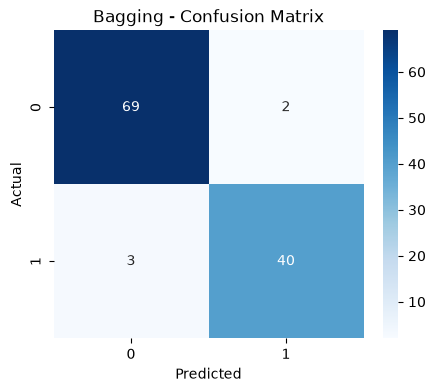

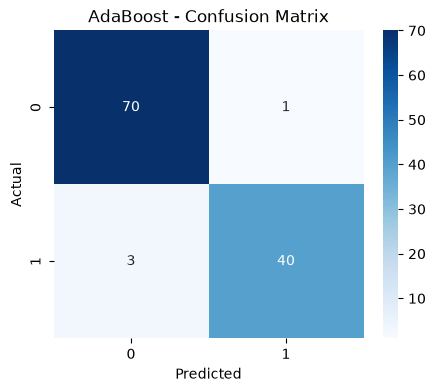

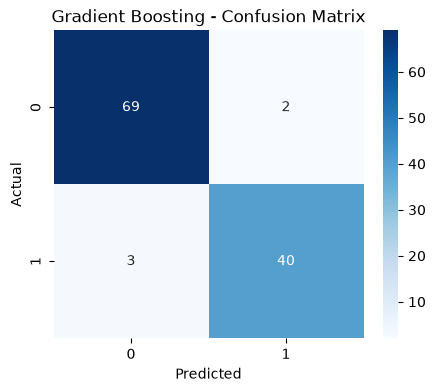

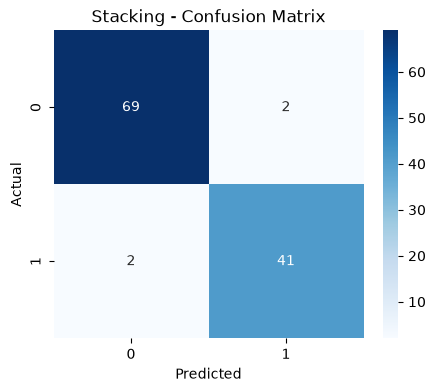

In [72]:
for name, predictions in models.items():

    cm = confusion_matrix(Y_test, predictions)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [73]:
y_score_bagging = best_bagging.predict_proba(X_test)[:, 1]
y_score_ada = best_ada.predict_proba(X_test)[:, 1]
y_score_gb = best_gb.predict_proba(X_test)[:, 1]
y_score_stacking = best_stacking.predict_proba(X_test)[:, 1]

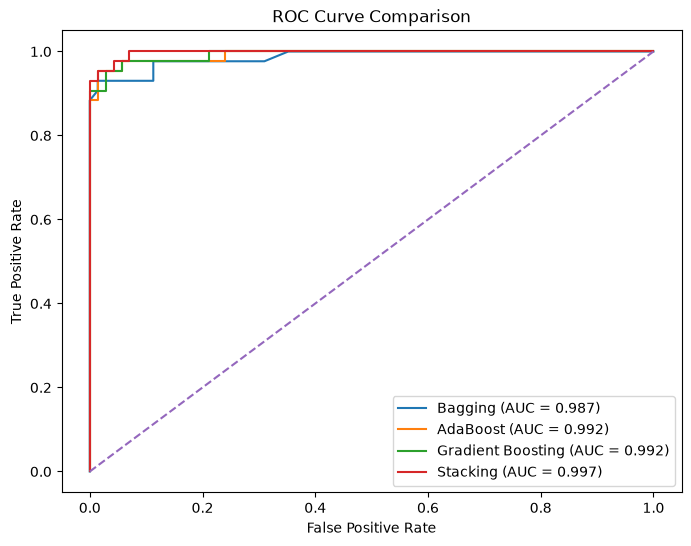

In [75]:
scores = {
    "Bagging": y_score_bagging,
    "AdaBoost": y_score_ada,
    "Gradient Boosting": y_score_gb,
    "Stacking": y_score_stacking
}

plt.figure(figsize=(8, 6))

for name, score in scores.items():

    fpr, tpr, thresholds = roc_curve(Y_test, score)
    auc_value = roc_auc_score(Y_test, score)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 8. Calculate AUC for Each Model

The ROC-AUC score is calculated for each ensemble model and displayed
for comparison.

In [77]:
auc_results = []

for name, score in scores.items():

    auc_value = roc_auc_score(Y_test, score)

    auc_results.append({
        "Model": name,
        "AUC": auc_value
    })

auc_df = pd.DataFrame(auc_results)

auc_df

,Model,AUC
0,Bagging,0.986571
1,AdaBoost,0.992139
2,Gradient Boosting,0.992466
3,Stacking,0.997052


## 9. Final Performance Comparison

The final test-set metrics of Bagging, AdaBoost, Gradient Boosting,
and Stacking are compared to determine the best-performing ensemble.

In [78]:
final_comparison = performance_df.merge(
    auc_df,
    on="Model"
)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Bagging,0.956140,0.952381,0.930233,0.941176,0.986571
1,AdaBoost,0.964912,0.975610,0.930233,0.952381,0.992139
2,Gradient Boosting,0.956140,0.952381,0.930233,0.941176,0.992466
3,Stacking,0.964912,0.953488,0.953488,0.953488,0.997052


In [79]:
best_model = final_comparison.loc[
    final_comparison["Accuracy"].idxmax()
]

best_model

Model        AdaBoost
Accuracy     0.964912
Precision     0.97561
Recall       0.930233
F1 Score     0.952381
AUC          0.992139
Name: 1, dtype: object